3-seed vit new

In [ ]:
import copy
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm


# =========================================================
# 1. Mount Drive and copy dataset to local disk
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/kaggle_cs3780_sp26")
DRIVE_DATA_DIR = DRIVE_ROOT / "lowdim_export" / "reduced_64x32"
LOCAL_ROOT = Path("/content/local_data")
LOCAL_DATA_DIR = LOCAL_ROOT / "reduced_64x32"

if LOCAL_DATA_DIR.exists():
    print(f"Local dataset already exists at {LOCAL_DATA_DIR}")
else:
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Copying dataset from {DRIVE_DATA_DIR} to {LOCAL_DATA_DIR} ...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy complete.")

print("Local train dir:", LOCAL_DATA_DIR / "train")
print("Local test dir:", LOCAL_DATA_DIR / "test")
print("Local solution:", LOCAL_DATA_DIR / "solution.csv")


# =========================================================
# 2. Config
# =========================================================
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
TEST_SUBDIR = Path("reduced_64x32/test")
SOLUTION_CSV = LOCAL_DATA_DIR / "solution.csv"

OUTPUT_DIR = DRIVE_ROOT / "vit_b_16_3seed_ensemble"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_SUMMARY_JSON = OUTPUT_DIR / "vit_b_16_3seed_ensemble_metrics.json"
OUTPUT_ENSEMBLE_CSV = OUTPUT_DIR / "vit_b_16_3seed_ensemble_submission.csv"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 22
WARMUP_EPOCHS = 2

LR_HEAD = 1e-3
LR_BACKBONE = 2e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
FREEZE_BACKBONE_EPOCHS = 2

NUM_WORKERS = 4
PATIENCE = 6
USE_AMP = True
USE_TTA = True

MIXUP_ALPHA = 0.2
USE_MIXUP = True
GRAD_CLIP_NORM = 1.0
EMA_DECAY = 0.999

SEEDS = [2026, 2027, 2028]


# =========================================================
# 3. Utilities
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def save_json(obj, path: Path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def model_num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


# =========================================================
# 4. Dataset
# =========================================================
class TrainFolderDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        if not self.classes:
            raise FileNotFoundError(f"No class folders found under {root_dir}")

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                self.samples.append((img_path, self.class_to_idx[cls_name]))

        if not self.samples:
            raise FileNotFoundError(f"No PNG files found under {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label


class TestWithSolutionDataset(Dataset):
    def __init__(self, test_dir: Path, solution_csv: Path, class_to_idx: dict[str, int], transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

        solution_df = pd.read_csv(solution_csv)
        if "file_name" not in solution_df.columns or "label" not in solution_df.columns:
            raise ValueError("solution.csv must contain columns: file_name, label")

        solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))

        self.samples = []
        image_paths = sorted(test_dir.rglob("*.png"))
        if not image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

        for img_path in image_paths:
            fname = img_path.name
            if fname not in solution_map:
                raise KeyError(f"{fname} not found in solution.csv")
            label_name = solution_map[fname]
            if label_name not in class_to_idx:
                raise KeyError(f"Label {label_name} from solution.csv not found in training classes")
            label_idx = class_to_idx[label_name]
            self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label, img_path.name


class TestUnlabeledDataset(Dataset):
    def __init__(self, test_dir: Path, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_paths = sorted(test_dir.rglob("*.png"))
        if not self.image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, img_path.name


# =========================================================
# 5. Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply(
        [transforms.RandomAffine(degrees=0, translate=(0.05, 0.05))],
        p=0.5,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# 6. Load data
# =========================================================
train_dir = BASE_DATA_ROOT / TRAIN_SUBDIR
test_dir = BASE_DATA_ROOT / TEST_SUBDIR

base_train_dataset = TrainFolderDataset(train_dir, transform=train_transform)
test_eval_dataset = TestWithSolutionDataset(
    test_dir=test_dir,
    solution_csv=SOLUTION_CSV,
    class_to_idx=base_train_dataset.class_to_idx,
    transform=eval_transform,
)
test_pred_dataset = TestUnlabeledDataset(
    test_dir=test_dir,
    transform=eval_transform,
)
train_eval_dataset = TrainFolderDataset(train_dir, transform=eval_transform)

persistent = NUM_WORKERS > 0

test_eval_loader = DataLoader(
    test_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_pred_loader = DataLoader(
    test_pred_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

num_classes = len(base_train_dataset.classes)
idx_to_class = base_train_dataset.idx_to_class

print("num_classes =", num_classes)
print("num_train =", len(base_train_dataset))
print("num_test =", len(test_eval_dataset))


# =========================================================
# 7. Model / EMA
# =========================================================
def build_model(num_classes: int):
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model


def freeze_backbone_except_head(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.heads.head.parameters():
        p.requires_grad = True


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + msd[k].detach() * (1.0 - self.decay))
            else:
                v.copy_(msd[k])


# =========================================================
# 8. Scheduler / Mixup
# =========================================================
def cosine_lr_lambda(current_epoch, total_epochs, warmup_epochs):
    if current_epoch < warmup_epochs:
        return float(current_epoch + 1) / float(max(1, warmup_epochs))
    progress = (current_epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
    return 0.5 * (1.0 + math.cos(math.pi * progress))


def make_optimizer(model, lr):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)


def mixup_batch(images, labels, alpha=0.2):
    if alpha <= 0:
        return images, labels, labels, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size, device=images.device)

    mixed_images = lam * images + (1 - lam) * images[index]
    labels_a = labels
    labels_b = labels[index]
    return mixed_images, labels_a, labels_b, lam


def mixup_loss(criterion, logits, labels_a, labels_b, lam):
    return lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)


# =========================================================
# 9. Train / Eval / Predict
# =========================================================
@torch.no_grad()
def run_eval_epoch(eval_model, loader, criterion, device, use_amp=True):
    eval_model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_file_names = []

    use_amp = use_amp and device.type == "cuda"

    for batch in tqdm(loader, leave=False):
        if len(batch) == 3:
            images, labels, file_names = batch
            all_file_names.extend(file_names)
        else:
            images, labels = batch

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = eval_model(images)
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), all_file_names


def run_train_epoch(model, ema_model, loader, criterion, optimizer, scaler, device, use_amp=True):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    use_amp = use_amp and device.type == "cuda"

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if USE_MIXUP:
            images, labels_a, labels_b, lam = mixup_batch(images, labels, MIXUP_ALPHA)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            if USE_MIXUP:
                loss = mixup_loss(criterion, logits, labels_a, labels_b, lam)
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        ema_model.update(model)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


@torch.no_grad()
def predict_logits(eval_model, loader, device, use_amp=True, use_tta=False):
    eval_model.eval()
    all_logits = []
    all_file_names = []
    use_amp = use_amp and device.type == "cuda"

    for images, file_names in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)

        if use_tta:
            variants = [
                images,
                torch.roll(images, shifts=1, dims=2),
                torch.roll(images, shifts=-1, dims=2),
                torch.roll(images, shifts=1, dims=3),
                torch.roll(images, shifts=-1, dims=3),
            ]
            logits_sum = 0
            for v in variants:
                with torch.autocast(device_type="cuda", enabled=use_amp):
                    logits_sum = logits_sum + eval_model(v)
            logits = logits_sum / len(variants)
        else:
            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits = eval_model(images)

        all_logits.append(logits.float().cpu())
        all_file_names.extend(list(file_names))

    all_logits = torch.cat(all_logits, dim=0).numpy()
    return all_logits, all_file_names


def logits_to_pred_df(logits: np.ndarray, file_names: list[str], idx_to_class: dict[int, str]):
    preds = logits.argmax(axis=1)
    if len(preds) != len(file_names):
        raise ValueError(f"Length mismatch: {len(preds)=}, {len(file_names)=}")
    return pd.DataFrame({
        "file_name": file_names,
        "label": [idx_to_class[int(i)] for i in preds],
    })


# =========================================================
# 10. One seed training
# =========================================================
def train_one_seed(seed: int):
    print("\n" + "=" * 80)
    print(f"Starting seed {seed}")
    set_seed(seed)

    seed_output_dir = OUTPUT_DIR / f"seed_{seed}"
    seed_output_dir.mkdir(parents=True, exist_ok=True)

    # train loader must be rebuilt after set_seed for shuffle determinism
    train_dataset = TrainFolderDataset(train_dir, transform=train_transform)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=persistent,
    )

    model = build_model(num_classes).to(DEVICE)
    ema_model = ModelEMA(model, decay=EMA_DECAY)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    freeze_backbone_except_head(model)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: cosine_lr_lambda(epoch, EPOCHS, WARMUP_EPOCHS)
    )

    history = []
    best_test_acc = -1.0
    best_epoch = -1
    best_state_dict = None
    best_ema_state_dict = None
    best_y_true = None
    best_y_pred = None
    epochs_without_improve = 0

    for epoch in range(1, EPOCHS + 1):
        if epoch == FREEZE_BACKBONE_EPOCHS + 1 and FREEZE_BACKBONE_EPOCHS > 0:
            print(f"[seed {seed}] Unfreezing full backbone at epoch {epoch}")
            unfreeze_all(model)
            optimizer = make_optimizer(model, LR_BACKBONE)
            scheduler = torch.optim.lr_scheduler.LambdaLR(
                optimizer,
                lr_lambda=lambda ep: cosine_lr_lambda(ep, max(EPOCHS - epoch + 1, 1), 1)
            )

        print(f"\n[seed {seed}] Epoch {epoch}/{EPOCHS}")

        train_loss, train_acc = run_train_epoch(
            model, ema_model, train_loader, criterion, optimizer, scaler, DEVICE, USE_AMP
        )

        test_loss, test_acc, y_true, y_pred, _ = run_eval_epoch(
            ema_model.ema, test_eval_loader, criterion, DEVICE, USE_AMP
        )

        print(f"[seed {seed}] train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")
        print(f"[seed {seed}] test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.6g}")

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "train_accuracy": float(train_acc),
            "test_loss": float(test_loss),
            "test_accuracy": float(test_acc),
            "lr": float(optimizer.param_groups[0]["lr"]),
        })

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            best_ema_state_dict = copy.deepcopy(ema_model.ema.state_dict())
            best_y_true = y_true.copy()
            best_y_pred = y_pred.copy()
            epochs_without_improve = 0

            best_logits, best_file_names = predict_logits(
                ema_model.ema,
                test_pred_loader,
                DEVICE,
                use_amp=USE_AMP,
                use_tta=USE_TTA,
            )
            best_pred_df = logits_to_pred_df(best_logits, best_file_names, idx_to_class)
            best_pred_df.to_csv(seed_output_dir / "best_test_predictions.csv", index=False)
            np.save(seed_output_dir / "best_test_logits.npy", best_logits)
            print(f"[seed {seed}] Saved new best logits/CSV at epoch {epoch}")
        else:
            epochs_without_improve += 1

        scheduler.step()

        if epochs_without_improve >= PATIENCE:
            print(f"[seed {seed}] Early stopping after {PATIENCE} epochs without improvement.")
            break

    ema_model.ema.load_state_dict(best_ema_state_dict)

    final_train_loss, final_train_acc, _, _, _ = run_eval_epoch(
        ema_model.ema, train_eval_loader, criterion, DEVICE, USE_AMP
    )

    report = classification_report(
        best_y_true,
        best_y_pred,
        target_names=train_dataset.classes,
        output_dict=True,
        zero_division=0,
    )

    metrics = {
        "seed": seed,
        "config": {
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "warmup_epochs": WARMUP_EPOCHS,
            "lr_head": LR_HEAD,
            "lr_backbone": LR_BACKBONE,
            "weight_decay": WEIGHT_DECAY,
            "label_smoothing": LABEL_SMOOTHING,
            "freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
            "patience": PATIENCE,
            "device": str(DEVICE),
            "model": "vit_b_16_improved",
            "use_tta": USE_TTA,
            "use_mixup": USE_MIXUP,
            "mixup_alpha": MIXUP_ALPHA,
            "ema_decay": EMA_DECAY,
            "grad_clip_norm": GRAD_CLIP_NORM,
        },
        "num_train": len(train_dataset),
        "num_test": len(test_eval_dataset),
        "num_classes": num_classes,
        "classes": train_dataset.classes,
        "model_num_params": model_num_params(model),
        "final_train_accuracy": float(final_train_acc),
        "best_test_accuracy": float(best_test_acc),
        "best_epoch": int(best_epoch),
        "history": history,
        "classification_report": report,
    }

    save_json(metrics, seed_output_dir / "metrics.json")
    torch.save({
        "model_state_dict": best_state_dict,
        "ema_state_dict": best_ema_state_dict,
        "classes": train_dataset.classes,
        "best_epoch": best_epoch,
        "best_test_accuracy": best_test_acc,
        "seed": seed,
    }, seed_output_dir / "best_model.pt")

    return {
        "seed": seed,
        "best_test_accuracy": float(best_test_acc),
        "best_epoch": int(best_epoch),
        "final_train_accuracy": float(final_train_acc),
        "logits_path": str(seed_output_dir / "best_test_logits.npy"),
        "csv_path": str(seed_output_dir / "best_test_predictions.csv"),
    }


# =========================================================
# 11. Train all 3 seeds
# =========================================================
seed_summaries = []
all_seed_logits = []
reference_file_names = None

for seed in SEEDS:
    summary = train_one_seed(seed)
    seed_summaries.append(summary)

    logits = np.load(summary["logits_path"])
    all_seed_logits.append(logits)

    # recover file order from one of the saved CSVs
    pred_df = pd.read_csv(summary["csv_path"])
    file_names = pred_df["file_name"].tolist()

    if reference_file_names is None:
        reference_file_names = file_names
    else:
        if reference_file_names != file_names:
            raise ValueError("File order mismatch across seeds. Cannot ensemble safely.")


# =========================================================
# 12. Ensemble logits and save final submission
# =========================================================
ensemble_logits = np.mean(np.stack(all_seed_logits, axis=0), axis=0)
ensemble_pred_df = logits_to_pred_df(ensemble_logits, reference_file_names, idx_to_class)
ensemble_pred_df.to_csv(OUTPUT_ENSEMBLE_CSV, index=False)

# evaluate ensemble on solution.csv
solution_df = pd.read_csv(SOLUTION_CSV)
solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))
y_true_labels = [solution_map[f] for f in reference_file_names]
y_pred_labels = ensemble_pred_df["label"].tolist()
ensemble_test_acc = float(np.mean(np.array(y_true_labels) == np.array(y_pred_labels)))

summary = {
    "seeds": SEEDS,
    "seed_summaries": seed_summaries,
    "ensemble_test_accuracy": ensemble_test_acc,
    "ensemble_csv": str(OUTPUT_ENSEMBLE_CSV),
}

save_json(summary, OUTPUT_SUMMARY_JSON)

print("\n==== Final Ensemble Results ====")
for row in seed_summaries:
    print(
        f"seed={row['seed']} "
        f"train={row['final_train_accuracy']:.4f} "
        f"test={row['best_test_accuracy']:.4f} "
        f"best_epoch={row['best_epoch']}"
    )

print(f"ensemble_test_accuracy={ensemble_test_acc:.4f}")
print(f"Saved ensemble metrics to {OUTPUT_SUMMARY_JSON}")
print(f"Saved final ensemble submission to {OUTPUT_ENSEMBLE_CSV}")

ensemble_pred_df.head()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Error initializing TrainFolderDataset: [Errno 2] No such file or directory: '/content/local_data/reduced_64x32/train'
Attempting to infer classes from solution CSV.


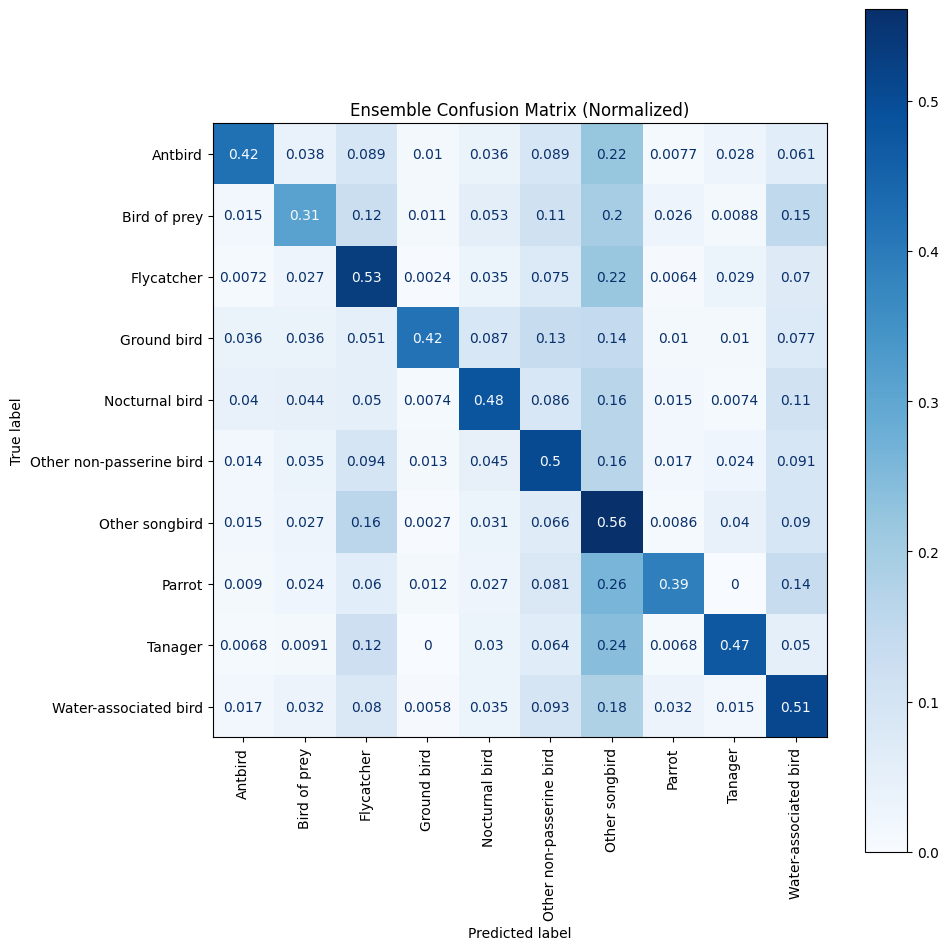

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import pandas as pd # Import pandas for CSV reading

# --- Define paths to prediction and solution CSVs ---
PREDICTION_CSV_PATH = Path("/content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_single_run/vit_b_16_best_test_predictions.csv")
SOLUTION_CSV_PATH = Path("/content/local_data/reduced_64x32/solution.csv")

# --- Minimal definitions needed to get num_classes and idx_to_class ---
LOCAL_ROOT = Path("/content/local_data")
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
IMG_SIZE = 224 # From config

# Redefine TrainFolderDataset class
class TrainFolderDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        if not self.classes:
            raise FileNotFoundError(f"No class folders found under {root_dir}")

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                self.samples.append((img_path, self.class_to_idx[cls_name]))

        if not self.samples:
            # This case indicates an empty directory or no images, not necessarily an error
            # if we only need class definitions.
            print(f"Warning: No PNG files found under {root_dir}. Proceeding with class definitions only.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label

# Redefine eval_transform
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load data to get num_classes and idx_to_class
try:
    train_dir = BASE_DATA_ROOT / TRAIN_SUBDIR
    base_train_dataset = TrainFolderDataset(train_dir, transform=eval_transform)
    num_classes = len(base_train_dataset.classes)
    idx_to_class = base_train_dataset.idx_to_class
    class_names = [idx_to_class[i] for i in range(num_classes)]
except FileNotFoundError as e:
    print(f"Error initializing TrainFolderDataset: {e}")
    print("Attempting to infer classes from solution CSV.")
    solution_df = pd.read_csv(SOLUTION_CSV_PATH)
    unique_labels = solution_df['label'].unique()
    unique_labels.sort()
    class_names = list(unique_labels)
    idx_to_class = {i: name for i, name in enumerate(class_names)}
    num_classes = len(class_names)

# --- Load prediction and solution CSVs ---
pred_df = pd.read_csv(PREDICTION_CSV_PATH)
solution_df = pd.read_csv(SOLUTION_CSV_PATH)

# Merge dataframes on 'file_name' to align predictions with true labels
merged_df = pd.merge(pred_df, solution_df, on='file_name', suffixes=('_pred', '_true'))

# Extract true and predicted labels
y_true_labels = merged_df['label_true'].tolist()
y_pred_labels = merged_df['label_pred'].tolist()

# Map string labels to integer indices using idx_to_class for consistent plotting
y_true_indices = [class_names.index(label) for label in y_true_labels]
y_pred_indices = [class_names.index(label) for label in y_pred_labels]

# --- Plot Confusion Matrix ---
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_true=y_true_indices,
    y_pred=y_pred_indices,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax
)
ax.set_title("Ensemble Confusion Matrix (Normalized)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import copy
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm


# =========================================================
# 1. Mount Drive and copy dataset to local disk
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/kaggle_cs3780_sp26")
DRIVE_DATA_DIR = DRIVE_ROOT / "lowdim_export" / "reduced_64x32"
LOCAL_ROOT = Path("/content/local_data")
LOCAL_DATA_DIR = LOCAL_ROOT / "reduced_64x32"

if LOCAL_DATA_DIR.exists():
    print(f"Local dataset already exists at {LOCAL_DATA_DIR}")
else:
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Copying dataset from {DRIVE_DATA_DIR} to {LOCAL_DATA_DIR} ...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy complete.")

print("Local train dir:", LOCAL_DATA_DIR / "train")
print("Local test dir:", LOCAL_DATA_DIR / "test")
print("Local solution:", LOCAL_DATA_DIR / "solution.csv")


# =========================================================
# 2. Config
# =========================================================
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
TEST_SUBDIR = Path("reduced_64x32/test")
SOLUTION_CSV = LOCAL_DATA_DIR / "solution.csv"

OUTPUT_DIR = DRIVE_ROOT / "vit_b_16_single_run"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_JSON = OUTPUT_DIR / "vit_b_16_metrics.json"
OUTPUT_MODEL = OUTPUT_DIR / "vit_b_16_best.pt"
OUTPUT_PRED_CSV = OUTPUT_DIR / "vit_b_16_best_test_predictions.csv"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 16
LR = 3e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
FREEZE_BACKBONE_EPOCHS = 3
NUM_WORKERS = 4
PATIENCE = 5
SEED = 2026
USE_AMP = True


# =========================================================
# 3. Utilities
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =========================================================
# 4. Dataset
# =========================================================
class TrainFolderDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        if not self.classes:
            raise FileNotFoundError(f"No class folders found under {root_dir}")

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                self.samples.append((img_path, self.class_to_idx[cls_name]))

        if not self.samples:
            raise FileNotFoundError(f"No PNG files found under {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label


class TestWithSolutionDataset(Dataset):
    def __init__(self, test_dir: Path, solution_csv: Path, class_to_idx: dict[str, int], transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

        solution_df = pd.read_csv(solution_csv)
        if "file_name" not in solution_df.columns or "label" not in solution_df.columns:
            raise ValueError("solution.csv must contain columns: file_name, label")

        solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))

        self.samples = []
        image_paths = sorted(test_dir.rglob("*.png"))
        if not image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

        for img_path in image_paths:
            fname = img_path.name
            if fname not in solution_map:
                raise KeyError(f"{fname} not found in solution.csv")
            label_name = solution_map[fname]
            if label_name not in class_to_idx:
                raise KeyError(f"Label {label_name} from solution.csv not found in training classes")
            label_idx = class_to_idx[label_name]
            self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label, img_path.name


class TestUnlabeledDataset(Dataset):
    def __init__(self, test_dir: Path, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_paths = sorted(test_dir.rglob("*.png"))
        if not self.image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, img_path.name


# =========================================================
# 5. Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply(
        [transforms.RandomAffine(degrees=0, translate=(0.06, 0.06))],
        p=0.5,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# 6. Load data
# =========================================================
train_dir = BASE_DATA_ROOT / TRAIN_SUBDIR
test_dir = BASE_DATA_ROOT / TEST_SUBDIR

train_dataset = TrainFolderDataset(train_dir, transform=train_transform)
test_eval_dataset = TestWithSolutionDataset(
    test_dir=test_dir,
    solution_csv=SOLUTION_CSV,
    class_to_idx=train_dataset.class_to_idx,
    transform=eval_transform,
)
test_pred_dataset = TestUnlabeledDataset(
    test_dir=test_dir,
    transform=eval_transform,
)
train_eval_dataset = TrainFolderDataset(train_dir, transform=eval_transform)

persistent = NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_eval_loader = DataLoader(
    test_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_pred_loader = DataLoader(
    test_pred_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

num_classes = len(train_dataset.classes)
print("num_classes =", num_classes)
print("num_train =", len(train_dataset))
print("num_test =", len(test_eval_dataset))


# =========================================================
# 7. Model: ViT-B/16
# =========================================================
weights = models.ViT_B_16_Weights.DEFAULT
model = models.vit_b_16(weights=weights)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)
model = model.to(DEVICE)


def freeze_backbone_except_head(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.heads.head.parameters():
        p.requires_grad = True


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

freeze_backbone_except_head(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))


# =========================================================
# 8. Helpers
# =========================================================
def model_num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def save_json(obj, path: Path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def run_train_epoch(model, loader, criterion, optimizer, scaler, device, use_amp=True):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    use_amp = use_amp and device.type == "cuda"

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


@torch.no_grad()
def run_eval_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    use_amp = use_amp and device.type == "cuda"

    for images, labels, _ in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)


@torch.no_grad()
def predict_logits_unlabeled(model, loader, device, use_amp=True):
    model.eval()
    all_logits = []
    all_file_names = []

    use_amp = use_amp and device.type == "cuda"

    for images, file_names in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)

        all_logits.append(logits.float().cpu())
        all_file_names.extend(list(file_names))

    all_logits = torch.cat(all_logits, dim=0).numpy()
    return all_logits, all_file_names


def logits_to_pred_df(logits: np.ndarray, file_names: list[str], idx_to_class: dict[int, str]):
    preds = logits.argmax(axis=1)

    if len(preds) != len(file_names):
        raise ValueError(f"Length mismatch: {len(preds)=}, {len(file_names)=}")

    return pd.DataFrame({
        "file_name": file_names,
        "label": [idx_to_class[int(i)] for i in preds],
    })


# =========================================================
# 9. Training loop
# =========================================================
history = []
best_test_acc = -1.0
best_epoch = -1
best_state_dict = None
best_y_true = None
best_y_pred = None
epochs_without_improve = 0

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1 and FREEZE_BACKBONE_EPOCHS > 0:
        print(f"[vit_b_16] Unfreezing full backbone at epoch {epoch}")
        unfreeze_all(model)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(EPOCHS - epoch + 1, 1),
        )

    print(f"\n[vit_b_16] Epoch {epoch}/{EPOCHS}")

    train_loss, train_acc = run_train_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE, USE_AMP
    )
    test_loss, test_acc, y_true, y_pred = run_eval_epoch(
        model, test_eval_loader, criterion, DEVICE, USE_AMP
    )

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"[vit_b_16] train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")
    print(f"[vit_b_16] test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, lr={lr_now:.6g}")

    history.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_acc),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "lr": float(lr_now),
    })

    improved = test_acc > best_test_acc
    if improved:
        best_test_acc = test_acc
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        best_y_true = y_true.copy()
        best_y_pred = y_pred.copy()
        epochs_without_improve = 0

        best_logits, best_file_names = predict_logits_unlabeled(
            model, test_pred_loader, DEVICE, USE_AMP
        )
        best_pred_df = logits_to_pred_df(best_logits, best_file_names, train_dataset.idx_to_class)
        best_pred_df.to_csv(OUTPUT_PRED_CSV, index=False)
        print(f"[vit_b_16] Saved new best prediction CSV to {OUTPUT_PRED_CSV}")
    else:
        epochs_without_improve += 1

    scheduler.step()

    if epochs_without_improve >= PATIENCE:
        print(f"[vit_b_16] Early stopping after {PATIENCE} epochs without improvement.")
        break


# =========================================================
# 10. Reload best model and save outputs
# =========================================================
model.load_state_dict(best_state_dict)

final_train_loss, final_train_acc, _, _ = run_eval_epoch(
    model, train_eval_loader, criterion, DEVICE, USE_AMP
)

report = classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset.classes,
    output_dict=True,
    zero_division=0,
)

results = {
    "config": {
        "train_dir": str(train_dir),
        "test_dir": str(test_dir),
        "solution_csv": str(SOLUTION_CSV),
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
        "patience": PATIENCE,
        "seed": SEED,
        "device": str(DEVICE),
        "model": "vit_b_16",
    },
    "num_train": len(train_dataset),
    "num_test": len(test_eval_dataset),
    "num_classes": num_classes,
    "classes": train_dataset.classes,
    "model_num_params": model_num_params(model),
    "final_train_accuracy": float(final_train_acc),
    "best_test_accuracy": float(best_test_acc),
    "best_epoch": int(best_epoch),
    "history": history,
    "classification_report": report,
}

save_json(results, OUTPUT_JSON)

torch.save({
    "state_dict": best_state_dict,
    "classes": train_dataset.classes,
    "best_epoch": best_epoch,
    "best_test_accuracy": best_test_acc,
    "config": results["config"],
}, OUTPUT_MODEL)

print("\n==== Final Results ====")
print(f"vit_b_16 train={final_train_acc:.4f}, test={best_test_acc:.4f}, best_epoch={best_epoch}")
print(f"Saved metrics to {OUTPUT_JSON}")
print(f"Saved model to {OUTPUT_MODEL}")
print(f"Saved best test predictions to {OUTPUT_PRED_CSV}")

pd.read_csv(OUTPUT_PRED_CSV).head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying dataset from /content/drive/MyDrive/kaggle_cs3780_sp26/lowdim_export/reduced_64x32 to /content/local_data/reduced_64x32 ...
Copy complete.
Local train dir: /content/local_data/reduced_64x32/train
Local test dir: /content/local_data/reduced_64x32/test
Local solution: /content/local_data/reduced_64x32/solution.csv
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
num_classes = 10
num_train = 27908
num_test = 6960
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 218MB/s]



[vit_b_16] Epoch 1/16


  0%|          | 0/873 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

...

  0%|          | 0/873 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

[vit_b_16] train_loss=0.9235, train_acc=0.8341
[vit_b_16] test_loss=1.8405, test_acc=0.4832, lr=4.35873e-07
[vit_b_16] Early stopping after 5 epochs without improvement.


  0%|          | 0/873 [00:00<?, ?it/s]

ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
import copy
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm


# =========================================================
# 1. Mount Drive and copy dataset to local disk
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/kaggle_cs3780_sp26")
DRIVE_DATA_DIR = DRIVE_ROOT / "lowdim_export" / "reduced_64x32"
LOCAL_ROOT = Path("/content/local_data")
LOCAL_DATA_DIR = LOCAL_ROOT / "reduced_64x32"

if LOCAL_DATA_DIR.exists():
    print(f"Local dataset already exists at {LOCAL_DATA_DIR}")
else:
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Copying dataset from {DRIVE_DATA_DIR} to {LOCAL_DATA_DIR} ...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy complete.")

print("Local train dir:", LOCAL_DATA_DIR / "train")
print("Local test dir:", LOCAL_DATA_DIR / "test")
print("Local solution:", LOCAL_DATA_DIR / "solution.csv")


# =========================================================
# 2. Config
# =========================================================
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
TEST_SUBDIR = Path("reduced_64x32/test")
SOLUTION_CSV = LOCAL_DATA_DIR / "solution.csv"

OUTPUT_DIR = DRIVE_ROOT / "vit_b_16_improved"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_JSON = OUTPUT_DIR / "vit_b_16_improved_metrics.json"
OUTPUT_MODEL = OUTPUT_DIR / "vit_b_16_improved_best.pt"
OUTPUT_PRED_CSV = OUTPUT_DIR / "vit_b_16_improved_best_test_predictions.csv"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 22
WARMUP_EPOCHS = 2

LR_HEAD = 1e-3
LR_BACKBONE = 2e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
FREEZE_BACKBONE_EPOCHS = 2

NUM_WORKERS = 4
PATIENCE = 6
SEED = 2026
USE_AMP = True
USE_TTA = True

MIXUP_ALPHA = 0.2
USE_MIXUP = True
GRAD_CLIP_NORM = 1.0
EMA_DECAY = 0.999


# =========================================================
# 3. Utilities
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def save_json(obj, path: Path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def model_num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


# =========================================================
# 4. Dataset
# =========================================================
class TrainFolderDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        if not self.classes:
            raise FileNotFoundError(f"No class folders found under {root_dir}")

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                self.samples.append((img_path, self.class_to_idx[cls_name]))

        if not self.samples:
            raise FileNotFoundError(f"No PNG files found under {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label


class TestWithSolutionDataset(Dataset):
    def __init__(self, test_dir: Path, solution_csv: Path, class_to_idx: dict[str, int], transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

        solution_df = pd.read_csv(solution_csv)
        if "file_name" not in solution_df.columns or "label" not in solution_df.columns:
            raise ValueError("solution.csv must contain columns: file_name, label")

        solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))

        self.samples = []
        image_paths = sorted(test_dir.rglob("*.png"))
        if not image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

        for img_path in image_paths:
            fname = img_path.name
            if fname not in solution_map:
                raise KeyError(f"{fname} not found in solution.csv")
            label_name = solution_map[fname]
            if label_name not in class_to_idx:
                raise KeyError(f"Label {label_name} from solution.csv not found in training classes")
            label_idx = class_to_idx[label_name]
            self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label, img_path.name


class TestUnlabeledDataset(Dataset):
    def __init__(self, test_dir: Path, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_paths = sorted(test_dir.rglob("*.png"))
        if not self.image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, img_path.name


# =========================================================
# 5. Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply(
        [transforms.RandomAffine(degrees=0, translate=(0.05, 0.05))],
        p=0.5,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# 6. Load data
# =========================================================
train_dir = BASE_DATA_ROOT / TRAIN_SUBDIR
test_dir = BASE_DATA_ROOT / TEST_SUBDIR

train_dataset = TrainFolderDataset(train_dir, transform=train_transform)
test_eval_dataset = TestWithSolutionDataset(
    test_dir=test_dir,
    solution_csv=SOLUTION_CSV,
    class_to_idx=train_dataset.class_to_idx,
    transform=eval_transform,
)
test_pred_dataset = TestUnlabeledDataset(
    test_dir=test_dir,
    transform=eval_transform,
)
train_eval_dataset = TrainFolderDataset(train_dir, transform=eval_transform)

persistent = NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_eval_loader = DataLoader(
    test_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_pred_loader = DataLoader(
    test_pred_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

num_classes = len(train_dataset.classes)
print("num_classes =", num_classes)
print("num_train =", len(train_dataset))
print("num_test =", len(test_eval_dataset))


# =========================================================
# 7. Model
# =========================================================
weights = models.ViT_B_16_Weights.DEFAULT
model = models.vit_b_16(weights=weights)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)
model = model.to(DEVICE)


def freeze_backbone_except_head(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.heads.head.parameters():
        p.requires_grad = True


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + msd[k].detach() * (1.0 - self.decay))
            else:
                v.copy_(msd[k])


ema_model = ModelEMA(model, decay=EMA_DECAY)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

freeze_backbone_except_head(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY,
)
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))


# =========================================================
# 8. Scheduler
# =========================================================
def cosine_lr_lambda(current_epoch, total_epochs, warmup_epochs):
    if current_epoch < warmup_epochs:
        return float(current_epoch + 1) / float(max(1, warmup_epochs))
    progress = (current_epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
    return 0.5 * (1.0 + math.cos(math.pi * progress))


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: cosine_lr_lambda(epoch, EPOCHS, WARMUP_EPOCHS)
)


# =========================================================
# 9. Mixup
# =========================================================
def mixup_batch(images, labels, alpha=0.2):
    if alpha <= 0:
        return images, labels, labels, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size, device=images.device)

    mixed_images = lam * images + (1 - lam) * images[index]
    labels_a = labels
    labels_b = labels[index]
    return mixed_images, labels_a, labels_b, lam


def mixup_loss(criterion, logits, labels_a, labels_b, lam):
    return lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)


# =========================================================
# 10. Helpers
# =========================================================
def make_optimizer(model, lr):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)


@torch.no_grad()
def run_eval_epoch(eval_model, loader, criterion, device, use_amp=True):
    eval_model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_file_names = []

    use_amp = use_amp and device.type == "cuda"

    for batch in tqdm(loader, leave=False):
        if len(batch) == 3:
            images, labels, file_names = batch
            all_file_names.extend(file_names)
        else:
            images, labels = batch

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = eval_model(images)
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), all_file_names


def run_train_epoch(model, ema_model, loader, criterion, optimizer, scaler, device, use_amp=True):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    use_amp = use_amp and device.type == "cuda"

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if USE_MIXUP:
            images, labels_a, labels_b, lam = mixup_batch(images, labels, MIXUP_ALPHA)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            if USE_MIXUP:
                loss = mixup_loss(criterion, logits, labels_a, labels_b, lam)
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        ema_model.update(model)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


@torch.no_grad()
def predict_test(eval_model, loader, idx_to_class, device, use_amp=True, use_tta=False):
    eval_model.eval()
    rows = []
    use_amp = use_amp and device.type == "cuda"

    for images, file_names in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)

        if use_tta:
            variants = [
                images,
                torch.roll(images, shifts=1, dims=2),
                torch.roll(images, shifts=-1, dims=2),
                torch.roll(images, shifts=1, dims=3),
                torch.roll(images, shifts=-1, dims=3),
            ]
            logits_sum = 0
            for v in variants:
                with torch.autocast(device_type="cuda", enabled=use_amp):
                    logits_sum = logits_sum + eval_model(v)
            logits = logits_sum / len(variants)
        else:
            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits = eval_model(images)

        preds = logits.argmax(dim=1).cpu().numpy()

        for fname, pred_idx in zip(file_names, preds):
            rows.append({
                "file_name": fname,
                "label": idx_to_class[int(pred_idx)],
            })

    return pd.DataFrame(rows)


# =========================================================
# 11. Training loop
# =========================================================
history = []
best_test_acc = -1.0
best_epoch = -1
best_state_dict = None
best_ema_state_dict = None
best_y_true = None
best_y_pred = None
epochs_without_improve = 0

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1 and FREEZE_BACKBONE_EPOCHS > 0:
        print(f"[vit_b_16_improved] Unfreezing full backbone at epoch {epoch}")
        unfreeze_all(model)
        optimizer = make_optimizer(model, LR_BACKBONE)
        scheduler = torch.optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda ep: cosine_lr_lambda(ep, max(EPOCHS - epoch + 1, 1), 1)
        )

    print(f"\n[vit_b_16_improved] Epoch {epoch}/{EPOCHS}")

    train_loss, train_acc = run_train_epoch(
        model, ema_model, train_loader, criterion, optimizer, scaler, DEVICE, USE_AMP
    )

    # 用 EMA 模型做评估，通常更稳
    test_loss, test_acc, y_true, y_pred, _ = run_eval_epoch(
        ema_model.ema, test_eval_loader, criterion, DEVICE, USE_AMP
    )

    print(f"[vit_b_16_improved] train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")
    print(f"[vit_b_16_improved] test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.6g}")

    history.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_acc),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "lr": float(optimizer.param_groups[0]["lr"]),
    })

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        best_ema_state_dict = copy.deepcopy(ema_model.ema.state_dict())
        best_y_true = y_true.copy()
        best_y_pred = y_pred.copy()
        epochs_without_improve = 0

        best_pred_df = predict_test(
            ema_model.ema,
            test_pred_loader,
            train_dataset.idx_to_class,
            DEVICE,
            use_amp=USE_AMP,
            use_tta=USE_TTA,
        )
        best_pred_df.to_csv(OUTPUT_PRED_CSV, index=False)
        print(f"[vit_b_16_improved] Saved new best prediction CSV at epoch {epoch} to {OUTPUT_PRED_CSV}")
    else:
        epochs_without_improve += 1

    scheduler.step()

    if epochs_without_improve >= PATIENCE:
        print(f"[vit_b_16_improved] Early stopping after {PATIENCE} epochs without improvement.")
        break


# =========================================================
# 12. Reload best EMA model
# =========================================================
ema_model.ema.load_state_dict(best_ema_state_dict)

final_train_loss, final_train_acc, _, _, _ = run_eval_epoch(
    ema_model.ema, train_eval_loader, criterion, DEVICE, USE_AMP
)

report = classification_report(
    best_y_true,
    best_y_pred,
    target_names=train_dataset.classes,
    output_dict=True,
    zero_division=0,
)

results = {
    "config": {
        "train_dir": str(train_dir),
        "test_dir": str(test_dir),
        "solution_csv": str(SOLUTION_CSV),
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "warmup_epochs": WARMUP_EPOCHS,
        "lr_head": LR_HEAD,
        "lr_backbone": LR_BACKBONE,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
        "patience": PATIENCE,
        "seed": SEED,
        "device": str(DEVICE),
        "model": "vit_b_16_improved",
        "use_tta": USE_TTA,
        "use_mixup": USE_MIXUP,
        "mixup_alpha": MIXUP_ALPHA,
        "ema_decay": EMA_DECAY,
        "grad_clip_norm": GRAD_CLIP_NORM,
    },
    "num_train": len(train_dataset),
    "num_test": len(test_eval_dataset),
    "num_classes": num_classes,
    "classes": train_dataset.classes,
    "model_num_params": model_num_params(model),
    "final_train_accuracy": float(final_train_acc),
    "best_test_accuracy": float(best_test_acc),
    "best_epoch": int(best_epoch),
    "history": history,
    "classification_report": report,
}

with OUTPUT_JSON.open("w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

torch.save({
    "model_state_dict": best_state_dict,
    "ema_state_dict": best_ema_state_dict,
    "classes": train_dataset.classes,
    "best_epoch": best_epoch,
    "best_test_accuracy": best_test_acc,
    "config": results["config"],
}, OUTPUT_MODEL)

print("\n==== Final Results ====")
print(f"vit_b_16_improved train={final_train_acc:.4f}, test={best_test_acc:.4f}, best_epoch={best_epoch}")
print(f"Saved metrics to {OUTPUT_JSON}")
print(f"Saved model to {OUTPUT_MODEL}")
print(f"Saved best test predictions to {OUTPUT_PRED_CSV}")

pd.read_csv(OUTPUT_PRED_CSV).head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local dataset already exists at /content/local_data/reduced_64x32
Local train dir: /content/local_data/reduced_64x32/train
Local test dir: /content/local_data/reduced_64x32/test
Local solution: /content/local_data/reduced_64x32/solution.csv
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
num_classes = 10
num_train = 27908
num_test = 6960

[vit_b_16_improved] Epoch 1/22


  0%|          | 0/873 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

[vit_b_16_improved] train_loss=2.0803, train_acc=0.2274
[vit_b_16_improved] test_loss=2.1029, test_acc=0.2592, lr=0.0005


  0%|          | 0/218 [00:00<?, ?it/s]

...

  0%|          | 0/218 [00:00<?, ?it/s]

[vit_b_16_improved] train_loss=1.3578, train_acc=0.4182
[vit_b_16_improved] test_loss=1.6815, test_acc=0.4917, lr=1.90983e-06
[vit_b_16_improved] Early stopping after 6 epochs without improvement.


  0%|          | 0/873 [00:00<?, ?it/s]


==== Final Results ====
vit_b_16_improved train=0.7184, test=0.4944, best_epoch=12
Saved metrics to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_improved/vit_b_16_improved_metrics.json
Saved model to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_improved/vit_b_16_improved_best.pt
Saved best test predictions to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_improved/vit_b_16_improved_best_test_predictions.csv


,file_name,label
0,XC1000276.png,Nocturnal bird
1,XC1000366.png,Bird of prey
2,XC1000546.png,Nocturnal bird
3,XC1000940.png,Other songbird
4,XC1000942.png,Other non-passerine bird


In [ ]:
import copy
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm


# =========================================================
# 1. Mount Drive and copy dataset to local disk
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/kaggle_cs3780_sp26")
DRIVE_DATA_DIR = DRIVE_ROOT / "lowdim_export" / "reduced_64x32"
LOCAL_ROOT = Path("/content/local_data")
LOCAL_DATA_DIR = LOCAL_ROOT / "reduced_64x32"

if LOCAL_DATA_DIR.exists():
    print(f"Local dataset already exists at {LOCAL_DATA_DIR}")
else:
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Copying dataset from {DRIVE_DATA_DIR} to {LOCAL_DATA_DIR} ...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy complete.")

print("Local train dir:", LOCAL_DATA_DIR / "train")
print("Local test dir:", LOCAL_DATA_DIR / "test")
print("Local solution:", LOCAL_DATA_DIR / "solution.csv")


# =========================================================
# 2. Config
# =========================================================
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
TEST_SUBDIR = Path("reduced_64x32/test")
SOLUTION_CSV = LOCAL_DATA_DIR / "solution.csv"

OUTPUT_DIR = DRIVE_ROOT / "vit_b_16_3seed_ensemble"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_SUMMARY_JSON = OUTPUT_DIR / "vit_b_16_3seed_ensemble_metrics.json"
OUTPUT_ENSEMBLE_CSV = OUTPUT_DIR / "vit_b_16_3seed_ensemble_submission.csv"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 22
WARMUP_EPOCHS = 2

LR_HEAD = 1e-3
LR_BACKBONE = 2e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
FREEZE_BACKBONE_EPOCHS = 2

NUM_WORKERS = 4
PATIENCE = 6
USE_AMP = True
USE_TTA = True

MIXUP_ALPHA = 0.2
USE_MIXUP = True
GRAD_CLIP_NORM = 1.0
EMA_DECAY = 0.999

SEEDS = [2026, 2027, 2028]


# =========================================================
# 3. Utilities
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def save_json(obj, path: Path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def model_num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


# =========================================================
# 4. Dataset
# =========================================================
class TrainFolderDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        if not self.classes:
            raise FileNotFoundError(f"No class folders found under {root_dir}")

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                self.samples.append((img_path, self.class_to_idx[cls_name]))

        if not self.samples:
            raise FileNotFoundError(f"No PNG files found under {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label


class TestWithSolutionDataset(Dataset):
    def __init__(self, test_dir: Path, solution_csv: Path, class_to_idx: dict[str, int], transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

        solution_df = pd.read_csv(solution_csv)
        if "file_name" not in solution_df.columns or "label" not in solution_df.columns:
            raise ValueError("solution.csv must contain columns: file_name, label")

        solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))

        self.samples = []
        image_paths = sorted(test_dir.rglob("*.png"))
        if not image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

        for img_path in image_paths:
            fname = img_path.name
            if fname not in solution_map:
                raise KeyError(f"{fname} not found in solution.csv")
            label_name = solution_map[fname]
            if label_name not in class_to_idx:
                raise KeyError(f"Label {label_name} from solution.csv not found in training classes")
            label_idx = class_to_idx[label_name]
            self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label, img_path.name


class TestUnlabeledDataset(Dataset):
    def __init__(self, test_dir: Path, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_paths = sorted(test_dir.rglob("*.png"))
        if not self.image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, img_path.name


# =========================================================
# 5. Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply(
        [transforms.RandomAffine(degrees=0, translate=(0.05, 0.05))],
        p=0.5,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# 6. Load data
# =========================================================
train_dir = BASE_DATA_ROOT / TRAIN_SUBDIR
test_dir = BASE_DATA_ROOT / TEST_SUBDIR

base_train_dataset = TrainFolderDataset(train_dir, transform=train_transform)
test_eval_dataset = TestWithSolutionDataset(
    test_dir=test_dir,
    solution_csv=SOLUTION_CSV,
    class_to_idx=base_train_dataset.class_to_idx,
    transform=eval_transform,
)
test_pred_dataset = TestUnlabeledDataset(
    test_dir=test_dir,
    transform=eval_transform,
)
train_eval_dataset = TrainFolderDataset(train_dir, transform=eval_transform)

persistent = NUM_WORKERS > 0

test_eval_loader = DataLoader(
    test_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_pred_loader = DataLoader(
    test_pred_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

num_classes = len(base_train_dataset.classes)
idx_to_class = base_train_dataset.idx_to_class

print("num_classes =", num_classes)
print("num_train =", len(base_train_dataset))
print("num_test =", len(test_eval_dataset))


# =========================================================
# 7. Model / EMA
# =========================================================
def build_model(num_classes: int):
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model


def freeze_backbone_except_head(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.heads.head.parameters():
        p.requires_grad = True


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + msd[k].detach() * (1.0 - self.decay))
            else:
                v.copy_(msd[k])


# =========================================================
# 8. Scheduler / Mixup
# =========================================================
def cosine_lr_lambda(current_epoch, total_epochs, warmup_epochs):
    if current_epoch < warmup_epochs:
        return float(current_epoch + 1) / float(max(1, warmup_epochs))
    progress = (current_epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
    return 0.5 * (1.0 + math.cos(math.pi * progress))


def make_optimizer(model, lr):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)


def mixup_batch(images, labels, alpha=0.2):
    if alpha <= 0:
        return images, labels, labels, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size, device=images.device)

    mixed_images = lam * images + (1 - lam) * images[index]
    labels_a = labels
    labels_b = labels[index]
    return mixed_images, labels_a, labels_b, lam


def mixup_loss(criterion, logits, labels_a, labels_b, lam):
    return lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)


# =========================================================
# 9. Train / Eval / Predict
# =========================================================
@torch.no_grad()
def run_eval_epoch(eval_model, loader, criterion, device, use_amp=True):
    eval_model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_file_names = []

    use_amp = use_amp and device.type == "cuda"

    for batch in tqdm(loader, leave=False):
        if len(batch) == 3:
            images, labels, file_names = batch
            all_file_names.extend(file_names)
        else:
            images, labels = batch

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = eval_model(images)
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), all_file_names


def run_train_epoch(model, ema_model, loader, criterion, optimizer, scaler, device, use_amp=True):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    use_amp = use_amp and device.type == "cuda"

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if USE_MIXUP:
            images, labels_a, labels_b, lam = mixup_batch(images, labels, MIXUP_ALPHA)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            if USE_MIXUP:
                loss = mixup_loss(criterion, logits, labels_a, labels_b, lam)
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        ema_model.update(model)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


@torch.no_grad()
def predict_logits(eval_model, loader, device, use_amp=True, use_tta=False):
    eval_model.eval()
    all_logits = []
    all_file_names = []
    use_amp = use_amp and device.type == "cuda"

    for images, file_names in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)

        if use_tta:
            variants = [
                images,
                torch.roll(images, shifts=1, dims=2),
                torch.roll(images, shifts=-1, dims=2),
                torch.roll(images, shifts=1, dims=3),
                torch.roll(images, shifts=-1, dims=3),
            ]
            logits_sum = 0
            for v in variants:
                with torch.autocast(device_type="cuda", enabled=use_amp):
                    logits_sum = logits_sum + eval_model(v)
            logits = logits_sum / len(variants)
        else:
            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits = eval_model(images)

        all_logits.append(logits.float().cpu())
        all_file_names.extend(list(file_names))

    all_logits = torch.cat(all_logits, dim=0).numpy()
    return all_logits, all_file_names


def logits_to_pred_df(logits: np.ndarray, file_names: list[str], idx_to_class: dict[int, str]):
    preds = logits.argmax(axis=1)
    if len(preds) != len(file_names):
        raise ValueError(f"Length mismatch: {len(preds)=}, {len(file_names)=}")
    return pd.DataFrame({
        "file_name": file_names,
        "label": [idx_to_class[int(i)] for i in preds],
    })


# =========================================================
# 10. One seed training
# =========================================================
def train_one_seed(seed: int):
    print("\n" + "=" * 80)
    print(f"Starting seed {seed}")
    set_seed(seed)

    seed_output_dir = OUTPUT_DIR / f"seed_{seed}"
    seed_output_dir.mkdir(parents=True, exist_ok=True)

    # train loader must be rebuilt after set_seed for shuffle determinism
    train_dataset = TrainFolderDataset(train_dir, transform=train_transform)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=persistent,
    )

    model = build_model(num_classes).to(DEVICE)
    ema_model = ModelEMA(model, decay=EMA_DECAY)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    freeze_backbone_except_head(model)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: cosine_lr_lambda(epoch, EPOCHS, WARMUP_EPOCHS)
    )

    history = []
    best_test_acc = -1.0
    best_epoch = -1
    best_state_dict = None
    best_ema_state_dict = None
    best_y_true = None
    best_y_pred = None
    epochs_without_improve = 0

    for epoch in range(1, EPOCHS + 1):
        if epoch == FREEZE_BACKBONE_EPOCHS + 1 and FREEZE_BACKBONE_EPOCHS > 0:
            print(f"[seed {seed}] Unfreezing full backbone at epoch {epoch}")
            unfreeze_all(model)
            optimizer = make_optimizer(model, LR_BACKBONE)
            scheduler = torch.optim.lr_scheduler.LambdaLR(
                optimizer,
                lr_lambda=lambda ep: cosine_lr_lambda(ep, max(EPOCHS - epoch + 1, 1), 1)
            )

        print(f"\n[seed {seed}] Epoch {epoch}/{EPOCHS}")

        train_loss, train_acc = run_train_epoch(
            model, ema_model, train_loader, criterion, optimizer, scaler, DEVICE, USE_AMP
        )

        test_loss, test_acc, y_true, y_pred, _ = run_eval_epoch(
            ema_model.ema, test_eval_loader, criterion, DEVICE, USE_AMP
        )

        print(f"[seed {seed}] train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")
        print(f"[seed {seed}] test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.6g}")

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "train_accuracy": float(train_acc),
            "test_loss": float(test_loss),
            "test_accuracy": float(test_acc),
            "lr": float(optimizer.param_groups[0]["lr"]),
        })

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            best_ema_state_dict = copy.deepcopy(ema_model.ema.state_dict())
            best_y_true = y_true.copy()
            best_y_pred = y_pred.copy()
            epochs_without_improve = 0

            best_logits, best_file_names = predict_logits(
                ema_model.ema,
                test_pred_loader,
                DEVICE,
                use_amp=USE_AMP,
                use_tta=USE_TTA,
            )
            best_pred_df = logits_to_pred_df(best_logits, best_file_names, idx_to_class)
            best_pred_df.to_csv(seed_output_dir / "best_test_predictions.csv", index=False)
            np.save(seed_output_dir / "best_test_logits.npy", best_logits)
            print(f"[seed {seed}] Saved new best logits/CSV at epoch {epoch}")
        else:
            epochs_without_improve += 1

        scheduler.step()

        if epochs_without_improve >= PATIENCE:
            print(f"[seed {seed}] Early stopping after {PATIENCE} epochs without improvement.")
            break

    ema_model.ema.load_state_dict(best_ema_state_dict)

    final_train_loss, final_train_acc, _, _, _ = run_eval_epoch(
        ema_model.ema, train_eval_loader, criterion, DEVICE, USE_AMP
    )

    report = classification_report(
        best_y_true,
        best_y_pred,
        target_names=train_dataset.classes,
        output_dict=True,
        zero_division=0,
    )

    metrics = {
        "seed": seed,
        "config": {
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "warmup_epochs": WARMUP_EPOCHS,
            "lr_head": LR_HEAD,
            "lr_backbone": LR_BACKBONE,
            "weight_decay": WEIGHT_DECAY,
            "label_smoothing": LABEL_SMOOTHING,
            "freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
            "patience": PATIENCE,
            "device": str(DEVICE),
            "model": "vit_b_16_improved",
            "use_tta": USE_TTA,
            "use_mixup": USE_MIXUP,
            "mixup_alpha": MIXUP_ALPHA,
            "ema_decay": EMA_DECAY,
            "grad_clip_norm": GRAD_CLIP_NORM,
        },
        "num_train": len(train_dataset),
        "num_test": len(test_eval_dataset),
        "num_classes": num_classes,
        "classes": train_dataset.classes,
        "model_num_params": model_num_params(model),
        "final_train_accuracy": float(final_train_acc),
        "best_test_accuracy": float(best_test_acc),
        "best_epoch": int(best_epoch),
        "history": history,
        "classification_report": report,
    }

    save_json(metrics, seed_output_dir / "metrics.json")
    torch.save({
        "model_state_dict": best_state_dict,
        "ema_state_dict": best_ema_state_dict,
        "classes": train_dataset.classes,
        "best_epoch": best_epoch,
        "best_test_accuracy": best_test_acc,
        "seed": seed,
    }, seed_output_dir / "best_model.pt")

    return {
        "seed": seed,
        "best_test_accuracy": float(best_test_acc),
        "best_epoch": int(best_epoch),
        "final_train_accuracy": float(final_train_acc),
        "logits_path": str(seed_output_dir / "best_test_logits.npy"),
        "csv_path": str(seed_output_dir / "best_test_predictions.csv"),
    }


# =========================================================
# 11. Train all 3 seeds
# =========================================================
seed_summaries = []
all_seed_logits = []
reference_file_names = None

for seed in SEEDS:
    summary = train_one_seed(seed)
    seed_summaries.append(summary)

    logits = np.load(summary["logits_path"])
    all_seed_logits.append(logits)

    # recover file order from one of the saved CSVs
    pred_df = pd.read_csv(summary["csv_path"])
    file_names = pred_df["file_name"].tolist()

    if reference_file_names is None:
        reference_file_names = file_names
    else:
        if reference_file_names != file_names:
            raise ValueError("File order mismatch across seeds. Cannot ensemble safely.")


# =========================================================
# 12. Ensemble logits and save final submission
# =========================================================
ensemble_logits = np.mean(np.stack(all_seed_logits, axis=0), axis=0)
ensemble_pred_df = logits_to_pred_df(ensemble_logits, reference_file_names, idx_to_class)
ensemble_pred_df.to_csv(OUTPUT_ENSEMBLE_CSV, index=False)

# evaluate ensemble on solution.csv
solution_df = pd.read_csv(SOLUTION_CSV)
solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))
y_true_labels = [solution_map[f] for f in reference_file_names]
y_pred_labels = ensemble_pred_df["label"].tolist()
ensemble_test_acc = float(np.mean(np.array(y_true_labels) == np.array(y_pred_labels)))

summary = {
    "seeds": SEEDS,
    "seed_summaries": seed_summaries,
    "ensemble_test_accuracy": ensemble_test_acc,
    "ensemble_csv": str(OUTPUT_ENSEMBLE_CSV),
}

save_json(summary, OUTPUT_SUMMARY_JSON)

print("\n==== Final Ensemble Results ====")
for row in seed_summaries:
    print(
        f"seed={row['seed']} "
        f"train={row['final_train_accuracy']:.4f} "
        f"test={row['best_test_accuracy']:.4f} "
        f"best_epoch={row['best_epoch']}"
    )

print(f"ensemble_test_accuracy={ensemble_test_acc:.4f}")
print(f"Saved ensemble metrics to {OUTPUT_SUMMARY_JSON}")
print(f"Saved final ensemble submission to {OUTPUT_ENSEMBLE_CSV}")

ensemble_pred_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local dataset already exists at /content/local_data/reduced_64x32
Local train dir: /content/local_data/reduced_64x32/train
Local test dir: /content/local_data/reduced_64x32/test
Local solution: /content/local_data/reduced_64x32/solution.csv
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
num_classes = 10
num_train = 27908
num_test = 6960

Starting seed 2026

[seed 2026] Epoch 1/22


  0%|          | 0/873 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

[seed 2026] train_loss=2.0803, train_acc=0.2274
[seed 2026] test_loss=2.1029, test_acc=0.2592, lr=0.0005


  0%|          | 0/218 [00:00<?, ?it/s]

...

  0%|          | 0/218 [00:00<?, ?it/s]

[seed 2028] train_loss=1.4637, train_acc=0.4088
[seed 2028] test_loss=1.6652, test_acc=0.4921, lr=1.86603e-05
[seed 2028] Early stopping after 6 epochs without improvement.


  0%|          | 0/873 [00:00<?, ?it/s]


==== Final Ensemble Results ====
seed=2026 train=0.7184 test=0.4944 best_epoch=12
seed=2027 train=0.7901 test=0.4951 best_epoch=17
seed=2028 train=0.7010 test=0.4940 best_epoch=11
ensemble_test_accuracy=0.5063
Saved ensemble metrics to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_3seed_ensemble/vit_b_16_3seed_ensemble_metrics.json
Saved final ensemble submission to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_3seed_ensemble/vit_b_16_3seed_ensemble_submission.csv


,file_name,label
0,XC1000276.png,Nocturnal bird
1,XC1000366.png,Bird of prey
2,XC1000546.png,Nocturnal bird
3,XC1000940.png,Other songbird
4,XC1000942.png,Other non-passerine bird


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import shutil # Import shutil for file operations

# Assuming y_true_labels, y_pred_labels are available from the previous cell's execution.
# If not, you might need to re-run the ensemble section or define them here based on the `solution_df` and `ensemble_pred_df`.

# --- Start of added code to define num_classes and idx_to_class ---
# Minimal definitions needed to get num_classes and idx_to_class
LOCAL_ROOT = Path("/content/local_data")
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
IMG_SIZE = 224 # From config

# Check if the train directory for the dataset exists. If not, re-copy the full dataset.
data_train_dir_path = BASE_DATA_ROOT / TRAIN_SUBDIR
if not data_train_dir_path.exists():
    print(f"Dataset train directory not found at {data_train_dir_path}. Re-copying full dataset from Drive...")
    # Ensure necessary Path objects are defined for copying
    DRIVE_ROOT = Path("/content/drive/MyDrive/kaggle_cs3780_sp26")
    DRIVE_DATA_DIR = DRIVE_ROOT / "lowdim_export" / "reduced_64x32"
    LOCAL_ROOT = Path("/content/local_data")
    LOCAL_DATA_DIR = LOCAL_ROOT / "reduced_64x32"

    if LOCAL_DATA_DIR.exists():
        shutil.rmtree(LOCAL_DATA_DIR) # Remove potentially incomplete copy
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Dataset re-copy complete.")

# Redefine TrainFolderDataset class if not in global scope
class TrainFolderDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        if not self.classes:
            raise FileNotFoundError(f"No class folders found under {root_dir}")

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                self.samples.append((img_path, self.class_to_idx[cls_name]))

        if not self.samples:
            raise FileNotFoundError(f"No PNG files found under {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label

# Redefine eval_transform if not in global scope
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load data to get num_classes and idx_to_class
train_dir = BASE_DATA_ROOT / TRAIN_SUBDIR
base_train_dataset = TrainFolderDataset(train_dir, transform=eval_transform)
num_classes = len(base_train_dataset.classes)
idx_to_class = base_train_dataset.idx_to_class
# --- End of added code ---

# Reconstruct class names if needed (from idx_to_class used in logits_to_pred_df)
class_names = [idx_to_class[i] for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_true=y_true_labels,
    y_pred=y_pred_labels,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax
)
ax.set_title("Ensemble Confusion Matrix (Normalized)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Dataset train directory not found at /content/local_data/reduced_64x32/train. Re-copying full dataset from Drive...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/kaggle_cs3780_sp26/lowdim_export/reduced_64x32'

In [ ]:
import copy
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm


# =========================================================
# 1. Mount Drive and copy dataset to local disk
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/kaggle_cs3780_sp26")
DRIVE_DATA_DIR = DRIVE_ROOT / "lowdim_export" / "reduced_64x32"
LOCAL_ROOT = Path("/content/local_data")
LOCAL_DATA_DIR = LOCAL_ROOT / "reduced_64x32"

if LOCAL_DATA_DIR.exists():
    print(f"Local dataset already exists at {LOCAL_DATA_DIR}")
else:
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Copying dataset from {DRIVE_DATA_DIR} to {LOCAL_DATA_DIR} ...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy complete.")

print("Local train dir:", LOCAL_DATA_DIR / "train")
print("Local test dir:", LOCAL_DATA_DIR / "test")
print("Local solution:", LOCAL_DATA_DIR / "solution.csv")


# =========================================================
# 2. Config
# =========================================================
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
TEST_SUBDIR = Path("reduced_64x32/test")
SOLUTION_CSV = LOCAL_DATA_DIR / "solution.csv"

OUTPUT_DIR = DRIVE_ROOT / "vit_distilled_from_3seed_teacher"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_JSON = OUTPUT_DIR / "vit_distill_metrics.json"
OUTPUT_MODEL = OUTPUT_DIR / "vit_distill_best.pt"
OUTPUT_PRED_CSV = OUTPUT_DIR / "vit_distill_best_submission.csv"

CACHE_DIR = OUTPUT_DIR / "teacher_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CKPTS = [
    DRIVE_ROOT / "vit_b_16_3seed_ensemble/seed_2026/best_model.pt",
    DRIVE_ROOT / "vit_b_16_3seed_ensemble/seed_2027/best_model.pt",
    DRIVE_ROOT / "vit_b_16_3seed_ensemble/seed_2028/best_model.pt",
]

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
WARMUP_EPOCHS = 2

LR_HEAD = 1e-3
LR_BACKBONE = 2e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
FREEZE_BACKBONE_EPOCHS = 2
PATIENCE = 6
NUM_WORKERS = 4
SEED = 3030

USE_AMP = True
USE_TTA = True

# distillation
DISTILL_TEMPERATURE = 2.0
ALPHA_CE = 0.5
ALPHA_KD = 0.5


# =========================================================
# 3. Utilities
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def save_json(obj, path: Path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def model_num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def cosine_lr_lambda(current_epoch, total_epochs, warmup_epochs):
    if current_epoch < warmup_epochs:
        return float(current_epoch + 1) / float(max(1, warmup_epochs))
    progress = (current_epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
    return 0.5 * (1.0 + math.cos(math.pi * progress))


# =========================================================
# 4. Dataset
# =========================================================
class TrainFolderDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None, return_name=False):
        self.root_dir = root_dir
        self.transform = transform
        self.return_name = return_name

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        if not self.classes:
            raise FileNotFoundError(f"No class folders found under {root_dir}")

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                self.samples.append((img_path, self.class_to_idx[cls_name]))

        if not self.samples:
            raise FileNotFoundError(f"No PNG files found under {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        if self.return_name:
            return img, label, img_path.name
        return img, label


class TestWithSolutionDataset(Dataset):
    def __init__(self, test_dir: Path, solution_csv: Path, class_to_idx: dict[str, int], transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

        solution_df = pd.read_csv(solution_csv)
        if "file_name" not in solution_df.columns or "label" not in solution_df.columns:
            raise ValueError("solution.csv must contain columns: file_name, label")

        solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))

        self.samples = []
        image_paths = sorted(test_dir.rglob("*.png"))
        if not image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

        for img_path in image_paths:
            fname = img_path.name
            if fname not in solution_map:
                raise KeyError(f"{fname} not found in solution.csv")
            label_name = solution_map[fname]
            if label_name not in class_to_idx:
                raise KeyError(f"Label {label_name} from solution.csv not found in training classes")
            label_idx = class_to_idx[label_name]
            self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label, img_path.name


class TestUnlabeledDataset(Dataset):
    def __init__(self, test_dir: Path, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_paths = sorted(test_dir.rglob("*.png"))
        if not self.image_paths:
            raise FileNotFoundError(f"No PNG files found under {test_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, img_path.name


# =========================================================
# 5. Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply(
        [transforms.RandomAffine(degrees=0, translate=(0.05, 0.05))],
        p=0.5,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# 6. Build base datasets / loaders
# =========================================================
train_dir = BASE_DATA_ROOT / TRAIN_SUBDIR
test_dir = BASE_DATA_ROOT / TEST_SUBDIR

base_train_dataset = TrainFolderDataset(train_dir, transform=eval_transform, return_name=True)
idx_to_class = base_train_dataset.idx_to_class
class_to_idx = base_train_dataset.class_to_idx
num_classes = len(idx_to_class)

test_eval_dataset = TestWithSolutionDataset(
    test_dir=test_dir,
    solution_csv=SOLUTION_CSV,
    class_to_idx=class_to_idx,
    transform=eval_transform,
)
test_pred_dataset = TestUnlabeledDataset(
    test_dir=test_dir,
    transform=eval_transform,
)
train_eval_dataset = TrainFolderDataset(
    train_dir,
    transform=eval_transform,
    return_name=False,
)

persistent = NUM_WORKERS > 0

teacher_train_loader = DataLoader(
    base_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_eval_loader = DataLoader(
    test_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_pred_loader = DataLoader(
    test_pred_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

print("num_classes =", num_classes)
print("num_train =", len(base_train_dataset))
print("num_test =", len(test_eval_dataset))


# =========================================================
# 7. Model builders
# =========================================================
def build_vit(num_classes: int):
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model


def freeze_backbone_except_head(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.heads.head.parameters():
        p.requires_grad = True


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True


# =========================================================
# 8. Teacher ensemble loading
# =========================================================
def load_teacher_model(ckpt_path: Path, num_classes: int):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model = build_vit(num_classes)
    if "ema_state_dict" in ckpt:
        model.load_state_dict(ckpt["ema_state_dict"])
    elif "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    elif "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    else:
        raise KeyError(f"Could not find state dict in {ckpt_path}")
    model = model.to(DEVICE)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model


teachers = []
for p in TEACHER_CKPTS:
    print(f"Loading teacher: {p}")
    teachers.append(load_teacher_model(p, num_classes))


# =========================================================
# 9. Precompute teacher logits
# =========================================================
@torch.no_grad()
def ensemble_logits_for_loader(teachers, loader, device, use_amp=True):
    all_logits = []
    all_labels = []
    all_names = []

    use_amp = use_amp and device.type == "cuda"

    for batch in tqdm(loader, leave=False):
        if len(batch) == 3:
            images, labels, names = batch
            all_labels.extend(labels.numpy())
            all_names.extend(list(names))
        else:
            raise ValueError("Expected loader with (images, labels, names)")

        images = images.to(device, non_blocking=True)

        logits_sum = 0
        for teacher in teachers:
            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits_sum = logits_sum + teacher(images)

        logits = (logits_sum / len(teachers)).float().cpu()
        all_logits.append(logits)

    all_logits = torch.cat(all_logits, dim=0).numpy()
    all_labels = np.array(all_labels)
    return all_logits, all_labels, all_names


train_teacher_logits_path = CACHE_DIR / "train_teacher_logits.npy"
train_teacher_names_path = CACHE_DIR / "train_teacher_names.json"

if train_teacher_logits_path.exists() and train_teacher_names_path.exists():
    print("Loading cached train teacher logits...")
    train_teacher_logits = np.load(train_teacher_logits_path)
    with train_teacher_names_path.open("r", encoding="utf-8") as f:
        train_teacher_names = json.load(f)
else:
    print("Precomputing train teacher logits...")
    train_teacher_logits, _, train_teacher_names = ensemble_logits_for_loader(
        teachers, teacher_train_loader, DEVICE, USE_AMP
    )
    np.save(train_teacher_logits_path, train_teacher_logits)
    with train_teacher_names_path.open("w", encoding="utf-8") as f:
        json.dump(train_teacher_names, f)

print("train_teacher_logits shape:", train_teacher_logits.shape)


# =========================================================
# 10. Distillation training dataset
# =========================================================
name_to_teacher_idx = {name: i for i, name in enumerate(train_teacher_names)}

class DistillTrainDataset(Dataset):
    def __init__(self, root_dir: Path, teacher_logits: np.ndarray, name_to_idx: dict[str, int], transform=None):
        self.root_dir = root_dir
        self.teacher_logits = teacher_logits
        self.name_to_idx = name_to_idx
        self.transform = transform

        self.classes = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        self.samples = []
        for cls_name in self.classes:
            class_dir = root_dir / cls_name
            for img_path in sorted(class_dir.rglob("*.png")):
                name = img_path.name
                if name not in self.name_to_idx:
                    raise KeyError(f"{name} missing from teacher logits cache")
                teacher_idx = self.name_to_idx[name]
                self.samples.append((img_path, self.class_to_idx[cls_name], teacher_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, teacher_idx = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)

        teacher_logit = torch.tensor(self.teacher_logits[teacher_idx], dtype=torch.float32)
        return img, label, teacher_logit


distill_train_dataset = DistillTrainDataset(
    train_dir,
    teacher_logits=train_teacher_logits,
    name_to_idx=name_to_teacher_idx,
    transform=train_transform,
)

distill_train_loader = DataLoader(
    distill_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)


# =========================================================
# 11. Losses / helpers
# =========================================================
def distillation_kl(student_logits, teacher_logits, temperature=2.0):
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    return F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)


@torch.no_grad()
def run_eval_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_names = []

    use_amp = use_amp and device.type == "cuda"

    for batch in tqdm(loader, leave=False):
        if len(batch) == 3:
            images, labels, names = batch
            all_names.extend(list(names))
        else:
            images, labels = batch

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), all_names


def run_train_epoch_distill(model, loader, ce_criterion, optimizer, scaler, device, use_amp=True):
    model.train()
    total_loss = 0.0
    total_ce = 0.0
    total_kd = 0.0
    all_preds = []
    all_labels = []

    use_amp = use_amp and device.type == "cuda"

    for images, labels, teacher_logits in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        teacher_logits = teacher_logits.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            student_logits = model(images)
            ce_loss = ce_criterion(student_logits, labels)
            kd_loss = distillation_kl(student_logits, teacher_logits, DISTILL_TEMPERATURE)
            loss = ALPHA_CE * ce_loss + ALPHA_KD * kd_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        total_ce += ce_loss.item() * images.size(0)
        total_kd += kd_loss.item() * images.size(0)

        preds = student_logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    n = len(loader.dataset)
    return (
        total_loss / n,
        total_ce / n,
        total_kd / n,
        accuracy_score(all_labels, all_preds),
    )


@torch.no_grad()
def predict_logits(model, loader, device, use_amp=True, use_tta=False):
    model.eval()
    all_logits = []
    all_names = []
    use_amp = use_amp and device.type == "cuda"

    for images, names in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)

        if use_tta:
            variants = [
                images,
                torch.roll(images, shifts=1, dims=2),
                torch.roll(images, shifts=-1, dims=2),
                torch.roll(images, shifts=1, dims=3),
                torch.roll(images, shifts=-1, dims=3),
            ]
            logits_sum = 0
            for v in variants:
                with torch.autocast(device_type="cuda", enabled=use_amp):
                    logits_sum = logits_sum + model(v)
            logits = logits_sum / len(variants)
        else:
            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits = model(images)

        all_logits.append(logits.float().cpu())
        all_names.extend(list(names))

    all_logits = torch.cat(all_logits, dim=0).numpy()
    return all_logits, all_names


def logits_to_pred_df(logits: np.ndarray, file_names: list[str], idx_to_class: dict[int, str]):
    preds = logits.argmax(axis=1)
    if len(preds) != len(file_names):
        raise ValueError(f"Length mismatch: {len(preds)=}, {len(file_names)=}")
    return pd.DataFrame({
        "file_name": file_names,
        "label": [idx_to_class[int(i)] for i in preds],
    })


# =========================================================
# 12. Student model
# =========================================================
student = build_vit(num_classes).to(DEVICE)
freeze_backbone_except_head(student)

ce_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, student.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: cosine_lr_lambda(epoch, EPOCHS, WARMUP_EPOCHS)
)

scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))


# =========================================================
# 13. Train student with distillation
# =========================================================
history = []
best_test_acc = -1.0
best_epoch = -1
best_state_dict = None
best_y_true = None
best_y_pred = None
epochs_without_improve = 0

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1 and FREEZE_BACKBONE_EPOCHS > 0:
        print(f"[distilled_vit] Unfreezing full backbone at epoch {epoch}")
        unfreeze_all(student)
        optimizer = torch.optim.AdamW(
            student.parameters(),
            lr=LR_BACKBONE,
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda ep: cosine_lr_lambda(ep, max(EPOCHS - epoch + 1, 1), 1)
        )

    print(f"\n[distilled_vit] Epoch {epoch}/{EPOCHS}")

    train_loss, train_ce, train_kd, train_acc = run_train_epoch_distill(
        student,
        distill_train_loader,
        ce_criterion,
        optimizer,
        scaler,
        DEVICE,
        USE_AMP,
    )

    test_loss, test_acc, y_true, y_pred, _ = run_eval_epoch(
        student,
        test_eval_loader,
        ce_criterion,
        DEVICE,
        USE_AMP,
    )

    print(
        f"[distilled_vit] train_loss={train_loss:.4f}, "
        f"train_ce={train_ce:.4f}, train_kd={train_kd:.4f}, "
        f"train_acc={train_acc:.4f}"
    )
    print(
        f"[distilled_vit] test_loss={test_loss:.4f}, "
        f"test_acc={test_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.6g}"
    )

    history.append({
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_ce": float(train_ce),
        "train_kd": float(train_kd),
        "train_accuracy": float(train_acc),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "lr": float(optimizer.param_groups[0]["lr"]),
    })

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        best_state_dict = copy.deepcopy(student.state_dict())
        best_y_true = y_true.copy()
        best_y_pred = y_pred.copy()
        epochs_without_improve = 0

        best_logits, best_names = predict_logits(
            student,
            test_pred_loader,
            DEVICE,
            use_amp=USE_AMP,
            use_tta=USE_TTA,
        )
        best_pred_df = logits_to_pred_df(best_logits, best_names, idx_to_class)
        best_pred_df.to_csv(OUTPUT_PRED_CSV, index=False)
        print(f"[distilled_vit] Saved new best submission at epoch {epoch} to {OUTPUT_PRED_CSV}")
    else:
        epochs_without_improve += 1

    scheduler.step()

    if epochs_without_improve >= PATIENCE:
        print(f"[distilled_vit] Early stopping after {PATIENCE} epochs without improvement.")
        break


# =========================================================
# 14. Final save
# =========================================================
student.load_state_dict(best_state_dict)

final_train_loss, final_train_acc, _, _, _ = run_eval_epoch(
    student,
    train_eval_loader,
    ce_criterion,
    DEVICE,
    USE_AMP,
)

report = classification_report(
    best_y_true,
    best_y_pred,
    target_names=[idx_to_class[i] for i in range(num_classes)],
    output_dict=True,
    zero_division=0,
)

results = {
    "config": {
        "train_dir": str(train_dir),
        "test_dir": str(test_dir),
        "solution_csv": str(SOLUTION_CSV),
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "warmup_epochs": WARMUP_EPOCHS,
        "lr_head": LR_HEAD,
        "lr_backbone": LR_BACKBONE,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
        "patience": PATIENCE,
        "seed": SEED,
        "device": str(DEVICE),
        "teacher_ckpts": [str(p) for p in TEACHER_CKPTS],
        "teacher_type": "3-seed_vit_ensemble",
        "student_type": "vit_b_16",
        "distill_temperature": DISTILL_TEMPERATURE,
        "alpha_ce": ALPHA_CE,
        "alpha_kd": ALPHA_KD,
        "use_tta": USE_TTA,
    },
    "num_train": len(distill_train_dataset),
    "num_test": len(test_eval_dataset),
    "num_classes": num_classes,
    "classes": [idx_to_class[i] for i in range(num_classes)],
    "model_num_params": model_num_params(student),
    "final_train_accuracy": float(final_train_acc),
    "best_test_accuracy": float(best_test_acc),
    "best_epoch": int(best_epoch),
    "history": history,
    "classification_report": report,
}

save_json(results, OUTPUT_JSON)

torch.save({
    "model_state_dict": best_state_dict,
    "classes": [idx_to_class[i] for i in range(num_classes)],
    "best_epoch": best_epoch,
    "best_test_accuracy": best_test_acc,
    "config": results["config"],
}, OUTPUT_MODEL)

print("\n==== Final Distilled Results ====")
print(f"distilled_vit train={final_train_acc:.4f}, test={best_test_acc:.4f}, best_epoch={best_epoch}")
print(f"Saved metrics to {OUTPUT_JSON}")
print(f"Saved model to {OUTPUT_MODEL}")
print(f"Saved best submission to {OUTPUT_PRED_CSV}")

pd.read_csv(OUTPUT_PRED_CSV).head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local dataset already exists at /content/local_data/reduced_64x32
Local train dir: /content/local_data/reduced_64x32/train
Local test dir: /content/local_data/reduced_64x32/test
Local solution: /content/local_data/reduced_64x32/solution.csv
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
num_classes = 10
num_train = 27908
num_test = 6960
Loading teacher: /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_3seed_ensemble/seed_2026/best_model.pt
Loading teacher: /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_3seed_ensemble/seed_2027/best_model.pt
Loading teacher: /content/drive/MyDrive/kaggle_cs3780_sp26/vit_b_16_3seed_ensemble/seed_2028/best_model.pt
Precomputing train teacher logits...


  0%|          | 0/873 [00:00<?, ?it/s]

train_teacher_logits shape: (27908, 10)

[distilled_vit] Epoch 1/20


  0%|          | 0/873 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

...

  0%|          | 0/218 [00:00<?, ?it/s]

[distilled_vit] train_loss=0.5461, train_ce=0.9816, train_kd=0.1105, train_acc=0.8212
[distilled_vit] test_loss=1.6698, test_acc=0.4937, lr=5e-06
[distilled_vit] Early stopping after 6 epochs without improvement.


  0%|          | 0/873 [00:00<?, ?it/s]


==== Final Distilled Results ====
distilled_vit train=0.8113, test=0.4976, best_epoch=12
Saved metrics to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_distilled_from_3seed_teacher/vit_distill_metrics.json
Saved model to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_distilled_from_3seed_teacher/vit_distill_best.pt
Saved best submission to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_distilled_from_3seed_teacher/vit_distill_best_submission.csv


,file_name,label
0,XC1000276.png,Nocturnal bird
1,XC1000366.png,Bird of prey
2,XC1000546.png,Water-associated bird
3,XC1000940.png,Other songbird
4,XC1000942.png,Other songbird


In [ ]:
import copy
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from tqdm.auto import tqdm


# =========================================================
# 1. Mount Drive and copy dataset to local disk
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/kaggle_cs3780_sp26")
DRIVE_DATA_DIR = DRIVE_ROOT / "lowdim_export" / "reduced_64x32"
LOCAL_ROOT = Path("/content/local_data")
LOCAL_DATA_DIR = LOCAL_ROOT / "reduced_64x32"

if LOCAL_DATA_DIR.exists():
    print(f"Local dataset already exists at {LOCAL_DATA_DIR}")
else:
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Copying dataset from {DRIVE_DATA_DIR} to {LOCAL_DATA_DIR} ...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy complete.")


# =========================================================
# 2. Config
# =========================================================
BASE_DATA_ROOT = LOCAL_ROOT
TRAIN_SUBDIR = Path("reduced_64x32/train")
TEST_SUBDIR = Path("reduced_64x32/test")
SOLUTION_CSV = LOCAL_DATA_DIR / "solution.csv"

OUTPUT_DIR = DRIVE_ROOT / "vit_hard_example_reweight"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_JSON = OUTPUT_DIR / "vit_hard_example_reweight_metrics.json"
OUTPUT_MODEL = OUTPUT_DIR / "vit_hard_example_reweight_best.pt"
OUTPUT_PRED_CSV = OUTPUT_DIR / "vit_hard_example_reweight_submission.csv"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
SEED = 2026
USE_AMP = True
USE_TTA = True

VAL_SIZE = 0.15

# stage 1
STAGE1_EPOCHS = 14
STAGE1_WARMUP_EPOCHS = 2
STAGE1_LR_HEAD = 1e-3
STAGE1_LR_BACKBONE = 2e-5
STAGE1_WEIGHT_DECAY = 1e-4
STAGE1_LABEL_SMOOTHING = 0.1
FREEZE_BACKBONE_EPOCHS = 2
PATIENCE = 5

# stage 2
STAGE2_EPOCHS = 8
STAGE2_LR = 1e-5
STAGE2_WEIGHT_DECAY = 1e-4
HARD_WEIGHT_POWER = 2.0
HARD_WEIGHT_MIN = 1.0
HARD_WEIGHT_MAX = 5.0


# =========================================================
# 3. Utilities
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def save_json(obj, path: Path):
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def model_num_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def cosine_lr_lambda(current_epoch, total_epochs, warmup_epochs):
    if current_epoch < warmup_epochs:
        return float(current_epoch + 1) / float(max(1, warmup_epochs))
    progress = (current_epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
    return 0.5 * (1.0 + math.cos(math.pi * progress))


# =========================================================
# 4. Build file list first
# =========================================================
train_root = BASE_DATA_ROOT / TRAIN_SUBDIR
test_root = BASE_DATA_ROOT / TEST_SUBDIR

all_samples = []
classes = sorted([p.name for p in train_root.iterdir() if p.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

for cls in classes:
    class_dir = train_root / cls
    for img_path in sorted(class_dir.rglob("*.png")):
        all_samples.append((img_path, class_to_idx[cls], cls))

labels_for_split = [x[1] for x in all_samples]

train_indices, val_indices = train_test_split(
    np.arange(len(all_samples)),
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=labels_for_split,
)

train_indices = sorted(train_indices.tolist())
val_indices = sorted(val_indices.tolist())

print("num_total =", len(all_samples))
print("num_train =", len(train_indices))
print("num_val =", len(val_indices))


# =========================================================
# 5. Datasets
# =========================================================
class SplitDataset(Dataset):
    def __init__(self, all_samples, indices, transform=None, return_name=False):
        self.all_samples = all_samples
        self.indices = indices
        self.transform = transform
        self.return_name = return_name

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img_path, label, _ = self.all_samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        if self.return_name:
            return img, label, img_path.name, idx
        return img, label


class TestWithSolutionDataset(Dataset):
    def __init__(self, test_dir: Path, solution_csv: Path, class_to_idx: dict[str, int], transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

        solution_df = pd.read_csv(solution_csv)
        solution_map = dict(zip(solution_df["file_name"], solution_df["label"]))

        self.samples = []
        image_paths = sorted(test_dir.rglob("*.png"))
        for img_path in image_paths:
            fname = img_path.name
            label_name = solution_map[fname]
            label_idx = class_to_idx[label_name]
            self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, label, img_path.name


class TestUnlabeledDataset(Dataset):
    def __init__(self, test_dir: Path, transform=None):
        self.image_paths = sorted(test_dir.rglob("*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
        return img, img_path.name


# =========================================================
# 6. Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply(
        [transforms.RandomAffine(degrees=0, translate=(0.05, 0.05))],
        p=0.5,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# =========================================================
# 7. Load split datasets
# =========================================================
train_dataset_stage1 = SplitDataset(all_samples, train_indices, transform=train_transform, return_name=False)
train_dataset_eval = SplitDataset(all_samples, train_indices, transform=eval_transform, return_name=True)
val_dataset = SplitDataset(all_samples, val_indices, transform=eval_transform, return_name=True)

test_eval_dataset = TestWithSolutionDataset(
    test_root, SOLUTION_CSV, class_to_idx, transform=eval_transform
)
test_pred_dataset = TestUnlabeledDataset(test_root, transform=eval_transform)

persistent = NUM_WORKERS > 0

train_loader_stage1 = DataLoader(
    train_dataset_stage1,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

train_eval_loader = DataLoader(
    train_dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_eval_loader = DataLoader(
    test_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

test_pred_loader = DataLoader(
    test_pred_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

print("classes =", classes)
print("num_test =", len(test_eval_dataset))


# =========================================================
# 8. Model
# =========================================================
def build_vit(num_classes: int):
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model


def freeze_backbone_except_head(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.heads.head.parameters():
        p.requires_grad = True


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


model = build_vit(len(classes)).to(DEVICE)


# =========================================================
# 9. Eval / predict helpers
# =========================================================
@torch.no_grad()
def run_eval_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_names = []
    all_indices = []

    use_amp = use_amp and device.type == "cuda"

    for batch in tqdm(loader, leave=False):
        if len(batch) == 4:
            images, labels, names, indices = batch
            all_names.extend(list(names))
            all_indices.extend(list(indices.numpy()))
        elif len(batch) == 3:
            images, labels, names = batch
            all_names.extend(list(names))
        else:
            images, labels = batch

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), all_names, all_indices


@torch.no_grad()
def predict_test(model, loader, idx_to_class, device, use_amp=True, use_tta=False):
    model.eval()
    rows = []
    use_amp = use_amp and device.type == "cuda"

    for images, file_names in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)

        if use_tta:
            variants = [
                images,
                torch.roll(images, shifts=1, dims=2),
                torch.roll(images, shifts=-1, dims=2),
                torch.roll(images, shifts=1, dims=3),
                torch.roll(images, shifts=-1, dims=3),
            ]
            logits_sum = 0
            for v in variants:
                with torch.autocast(device_type="cuda", enabled=use_amp):
                    logits_sum = logits_sum + model(v)
            logits = logits_sum / len(variants)
        else:
            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits = model(images)

        preds = logits.argmax(dim=1).cpu().numpy()
        for fname, pred_idx in zip(file_names, preds):
            rows.append({
                "file_name": fname,
                "label": idx_to_class[int(pred_idx)],
            })

    return pd.DataFrame(rows)


@torch.no_grad()
def get_train_losses(model, loader, device, use_amp=True):
    model.eval()
    use_amp = use_amp and device.type == "cuda"
    loss_fn = nn.CrossEntropyLoss(reduction="none")

    per_sample = {}

    for images, labels, names, indices in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            losses = loss_fn(logits, labels)

        for idx, loss_val in zip(indices.cpu().numpy(), losses.cpu().numpy()):
            per_sample[int(idx)] = float(loss_val)

    return per_sample


def build_weighted_sampler(train_indices, per_sample_loss, power=2.0, wmin=1.0, wmax=5.0):
    losses = np.array([per_sample_loss[idx] for idx in train_indices], dtype=np.float32)
    losses = (losses - losses.min()) / (losses.max() - losses.min() + 1e-8)
    weights = wmin + (wmax - wmin) * (losses ** power)
    sampler = WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.double),
        num_samples=len(weights),
        replacement=True,
    )
    return sampler, weights


# =========================================================
# 10. Training helper
# =========================================================
def run_train_epoch(model, loader, criterion, optimizer, scaler, device, use_amp=True):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    use_amp = use_amp and device.type == "cuda"

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


# =========================================================
# 11. Stage 1: normal training
# =========================================================
criterion = nn.CrossEntropyLoss(label_smoothing=STAGE1_LABEL_SMOOTHING)

freeze_backbone_except_head(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR_HEAD,
    weight_decay=STAGE1_WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: cosine_lr_lambda(epoch, STAGE1_EPOCHS, STAGE1_WARMUP_EPOCHS)
)
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))

history = []
best_val_acc = -1.0
best_epoch = -1
best_state_dict = None
best_stage = "stage1"
epochs_without_improve = 0

print("\n===== Stage 1: normal training =====")

for epoch in range(1, STAGE1_EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        print(f"[stage1] Unfreezing full backbone at epoch {epoch}")
        unfreeze_all(model)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=STAGE1_LR_HEAD if False else STAGE1_LR_BACKBONE,
            weight_decay=STAGE1_WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda ep: cosine_lr_lambda(ep, max(STAGE1_EPOCHS - epoch + 1, 1), 1)
        )

    print(f"\n[stage1] Epoch {epoch}/{STAGE1_EPOCHS}")
    train_loss, train_acc = run_train_epoch(model, train_loader_stage1, criterion, optimizer, scaler, DEVICE, USE_AMP)
    val_loss, val_acc, y_true, y_pred, val_names, _ = run_eval_epoch(model, val_loader, criterion, DEVICE, USE_AMP)

    print(f"[stage1] train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")
    print(f"[stage1] val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.6g}")

    history.append({
        "stage": "stage1",
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_acc),
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "lr": float(optimizer.param_groups[0]["lr"]),
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        best_stage = "stage1"
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    scheduler.step()

    if epochs_without_improve >= PATIENCE:
        print(f"[stage1] Early stopping after {PATIENCE} epochs without improvement.")
        break


# =========================================================
# 12. Analyze val, but do NOT use val for training
# =========================================================
model.load_state_dict(best_state_dict)

val_loss, val_acc, y_true, y_pred, val_names, _ = run_eval_epoch(model, val_loader, criterion, DEVICE, USE_AMP)
val_report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    output_dict=True,
    zero_division=0,
)

print("\n===== Validation analysis =====")
print(f"Best stage1 val_acc = {best_val_acc:.4f}")
for cls in classes:
    print(f"{cls}: f1={val_report[cls]['f1-score']:.4f}, recall={val_report[cls]['recall']:.4f}")


# =========================================================
# 13. Stage 2: hard-example reweighting on TRAIN only
# =========================================================
print("\n===== Stage 2: hard example reweighting on train =====")

train_losses = get_train_losses(model, train_eval_loader, DEVICE, USE_AMP)
sampler, sample_weights = build_weighted_sampler(
    train_indices,
    train_losses,
    power=HARD_WEIGHT_POWER,
    wmin=HARD_WEIGHT_MIN,
    wmax=HARD_WEIGHT_MAX,
)

train_dataset_stage2 = SplitDataset(all_samples, train_indices, transform=train_transform, return_name=False)
train_loader_stage2 = DataLoader(
    train_dataset_stage2,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=STAGE2_LR,
    weight_decay=STAGE2_WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=STAGE2_EPOCHS)
epochs_without_improve = 0

for epoch in range(1, STAGE2_EPOCHS + 1):
    print(f"\n[stage2] Epoch {epoch}/{STAGE2_EPOCHS}")
    train_loss, train_acc = run_train_epoch(model, train_loader_stage2, criterion, optimizer, scaler, DEVICE, USE_AMP)
    val_loss, val_acc, y_true, y_pred, val_names, _ = run_eval_epoch(model, val_loader, criterion, DEVICE, USE_AMP)

    print(f"[stage2] train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")
    print(f"[stage2] val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.6g}")

    history.append({
        "stage": "stage2",
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_acc),
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "lr": float(optimizer.param_groups[0]["lr"]),
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        best_stage = "stage2"
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    scheduler.step()

    if epochs_without_improve >= PATIENCE:
        print(f"[stage2] Early stopping after {PATIENCE} epochs without improvement.")
        break


# =========================================================
# 14. Final evaluation and submission
# =========================================================
model.load_state_dict(best_state_dict)

final_train_loss, final_train_acc, _, _, _, _ = run_eval_epoch(model, train_eval_loader, criterion, DEVICE, USE_AMP)
final_val_loss, final_val_acc, final_val_y_true, final_val_y_pred, _, _ = run_eval_epoch(model, val_loader, criterion, DEVICE, USE_AMP)
test_loss, test_acc, test_y_true, test_y_pred, _, _ = run_eval_epoch(model, test_eval_loader, criterion, DEVICE, USE_AMP)

test_report = classification_report(
    test_y_true,
    test_y_pred,
    target_names=classes,
    output_dict=True,
    zero_division=0,
)

pred_df = predict_test(model, test_pred_loader, idx_to_class, DEVICE, USE_AMP, USE_TTA)
pred_df.to_csv(OUTPUT_PRED_CSV, index=False)

results = {
    "config": {
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "val_size": VAL_SIZE,
        "stage1_epochs": STAGE1_EPOCHS,
        "stage2_epochs": STAGE2_EPOCHS,
        "stage1_lr_head": STAGE1_LR_HEAD,
        "stage1_lr_backbone": STAGE1_LR_BACKBONE,
        "stage2_lr": STAGE2_LR,
        "hard_weight_power": HARD_WEIGHT_POWER,
        "hard_weight_min": HARD_WEIGHT_MIN,
        "hard_weight_max": HARD_WEIGHT_MAX,
        "seed": SEED,
        "model": "vit_b_16_hard_example_reweight",
    },
    "num_total": len(all_samples),
    "num_train": len(train_indices),
    "num_val": len(val_indices),
    "num_test": len(test_eval_dataset),
    "classes": classes,
    "model_num_params": model_num_params(model),
    "best_stage": best_stage,
    "best_epoch": int(best_epoch),
    "best_val_accuracy": float(best_val_acc),
    "final_train_accuracy": float(final_train_acc),
    "final_val_accuracy": float(final_val_acc),
    "test_accuracy": float(test_acc),
    "history": history,
    "val_classification_report": val_report,
    "test_classification_report": test_report,
}

save_json(results, OUTPUT_JSON)
torch.save(
    {
        "model_state_dict": best_state_dict,
        "classes": classes,
        "best_stage": best_stage,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_acc,
        "config": results["config"],
    },
    OUTPUT_MODEL,
)

print("\n==== Final Results ====")
print(f"best_stage={best_stage}, best_val={best_val_acc:.4f}, test={test_acc:.4f}")
print(f"Saved metrics to {OUTPUT_JSON}")
print(f"Saved model to {OUTPUT_MODEL}")
print(f"Saved submission to {OUTPUT_PRED_CSV}")
pred_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local dataset already exists at /content/local_data/reduced_64x32
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
num_total = 27908
num_train = 23721
num_val = 4187
classes = ['Antbird', 'Bird of prey', 'Flycatcher', 'Ground bird', 'Nocturnal bird', 'Other non-passerine bird', 'Other songbird', 'Parrot', 'Tanager', 'Water-associated bird']
num_test = 6960

===== Stage 1: normal training =====

[stage1] Epoch 1/14


  0%|          | 0/742 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

[stage1] train_loss=2.0598, train_acc=0.2690
[stage1] val_loss=2.0084, val_acc=0.2988, lr=0.0005

[stage1] Epoch 2/14


  0%|          | 0/742 [00:00<?, ?it/s]

...

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]


==== Final Results ====
best_stage=stage1, best_val=0.4805, test=0.4767
Saved metrics to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_hard_example_reweight/vit_hard_example_reweight_metrics.json
Saved model to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_hard_example_reweight/vit_hard_example_reweight_best.pt
Saved submission to /content/drive/MyDrive/kaggle_cs3780_sp26/vit_hard_example_reweight/vit_hard_example_reweight_submission.csv


,file_name,label
0,XC1000276.png,Nocturnal bird
1,XC1000366.png,Bird of prey
2,XC1000546.png,Nocturnal bird
3,XC1000940.png,Other songbird
4,XC1000942.png,Other non-passerine bird
